In [1]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml(data_id=42165, as_frame=True, return_X_y=True)
y = y.astype(float)

print("Размер X:", X.shape)
print("Числовых признаков:", X.select_dtypes(include="number").shape[1])
print("Признаков с пропусками:", X.isna().any().sum())
print("Цены домов:")
print(y.describe())

Размер X: (1460, 80)
Числовых признаков: 37
Признаков с пропусками: 19
Цены домов:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [2]:
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.dummy import DummyRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    DummyRegressor(strategy="median"),
    X_train, y_train,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    },
)

print("Baseline CV MAE:", round(-scores["test_mae"].mean()))
print("Baseline CV RMSE:", round(-scores["test_rmse"].mean()))

Baseline CV MAE: 54586
Baseline CV RMSE: 78860


In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X_train.select_dtypes(include="number").columns.drop(
    "Id", errors="ignore"
).tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])

ridge = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge(alpha=10.0)),
])

ridge_scores = cross_validate(
    ridge,
    X_train, y_train,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    },
)

print("Ridge CV MAE:", round(-ridge_scores["test_mae"].mean()))
print("Ridge CV RMSE:", round(-ridge_scores["test_rmse"].mean()))

Ridge CV MAE: 18037
Ridge CV RMSE: 31648


In [4]:
import pandas as pd

display(pd.DataFrame({
    "fold": range(1, 6),
    "MAE": -ridge_scores["test_mae"],
    "RMSE": -ridge_scores["test_rmse"],
}).round(0))

,fold,MAE,RMSE
0,1,18342.0,29523.0
1,2,17225.0,33226.0
2,3,18754.0,44745.0
3,4,17416.0,25247.0
4,5,18446.0,25500.0


In [5]:
from sklearn.base import clone

train_idx, val_idx = list(cv.split(X_train))[2]  # [2] — третий фолд

fold_model = clone(ridge)
fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])

actual = y_train.iloc[val_idx]
predicted = fold_model.predict(X_train.iloc[val_idx])

errors = pd.DataFrame({
    "actual": actual.to_numpy(),
    "predicted": predicted,
    "abs_error": abs(actual.to_numpy() - predicted),
}, index=actual.index)

display(errors.sort_values("abs_error", ascending=False).head(10).round(0))

,actual,predicted,abs_error
1298,160000.0,687586.0,527586.0
1182,745000.0,448842.0,296158.0
1423,274970.0,170135.0,104835.0
496,430000.0,366512.0,63488.0
798,485000.0,423175.0,61825.0
970,135000.0,73693.0,61307.0
810,181000.0,121114.0,59886.0
1322,190000.0,243648.0,53648.0
560,121500.0,173980.0,52480.0
46,239686.0,289955.0,50269.0


In [6]:
cols = ["GrLivArea", "OverallQual", "TotalBsmtSF", "SaleCondition"]

display(X_train.loc[[1298, 1182], cols])
display(X_train[cols[:3]].median().to_frame("медиана по train"))

,GrLivArea,OverallQual,TotalBsmtSF,SaleCondition
1298,5642,10,6110,Partial
1182,4476,10,2396,Abnorml


,медиана по train
GrLivArea,1473.0
OverallQual,6.0
TotalBsmtSF,997.5


In [7]:
import numpy as np
from sklearn.compose import TransformedTargetRegressor

log_ridge = TransformedTargetRegressor(
    regressor=ridge,
    func=np.log1p,
    inverse_func=np.expm1,
)

log_ridge_scores = cross_validate(
    log_ridge,
    X_train, y_train,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    },
)

print("Log-Ridge CV MAE:", round(-log_ridge_scores["test_mae"].mean()))
print("Log-Ridge CV RMSE:", round(-log_ridge_scores["test_rmse"].mean()))

Log-Ridge CV MAE: 17251
Log-Ridge CV RMSE: 40364


In [8]:
from sklearn.ensemble import RandomForestRegressor

random_forest = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_features=0.7,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1,
    )),
])

rf_scores = cross_validate(
    random_forest,
    X_train, y_train,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    },
    n_jobs=-1,
)

print("Random Forest CV MAE:", round(-rf_scores["test_mae"].mean()))
print("Random Forest CV RMSE:", round(-rf_scores["test_rmse"].mean()))

Random Forest CV MAE: 17792
Random Forest CV RMSE: 29777


In [9]:
comparison = pd.DataFrame({
    "fold": range(1, 6),
    "log_ridge_mae": -log_ridge_scores["test_mae"],
    "random_forest_mae": -rf_scores["test_mae"],
})

comparison["rf_minus_log_ridge"] = (
    comparison["random_forest_mae"] - comparison["log_ridge_mae"]
)

display(comparison.round(0))

print(
    "Log-Ridge MAE std:",
    round(comparison["log_ridge_mae"].std())
)
print(
    "Random Forest MAE std:",
    round(comparison["random_forest_mae"].std())
)

,fold,log_ridge_mae,random_forest_mae,rf_minus_log_ridge
0,1,16461.0,17510.0,1048.0
1,2,17077.0,18436.0,1358.0
2,3,20104.0,19059.0,-1045.0
3,4,16842.0,17201.0,359.0
4,5,15768.0,16755.0,987.0


Log-Ridge MAE std: 1670
Random Forest MAE std: 938


In [10]:
from sklearn.model_selection import GridSearchCV

ridge_search = GridSearchCV(
    estimator=log_ridge,
    param_grid={
        "regressor__model__alpha": [0.1, 1, 10, 30, 100, 300]
    },
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    },
    refit="mae",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

ridge_search.fit(X_train, y_train)

tuning_results = pd.DataFrame(ridge_search.cv_results_)[[
    "param_regressor__model__alpha",
    "mean_train_mae",
    "mean_test_mae",
    "std_test_mae",
    "mean_test_rmse",
]].copy()

for column in ["mean_train_mae", "mean_test_mae", "mean_test_rmse"]:
    tuning_results[column] = -tuning_results[column]

tuning_results = tuning_results.sort_values("mean_test_mae")

display(tuning_results.round(0))
print("Выбранный alpha:", ridge_search.best_params_)
print("Лучший CV MAE:", round(-ridge_search.best_score_))

,param_regressor__model__alpha,mean_train_mae,mean_test_mae,std_test_mae,mean_test_rmse
2,10.0,13409.0,17251.0,1494.0,40364.0
3,30.0,14227.0,17359.0,1517.0,40877.0
1,1.0,11920.0,17692.0,1841.0,43102.0
4,100.0,15317.0,17695.0,1486.0,42201.0
0,0.0,10907.0,18197.0,2265.0,47420.0
5,300.0,16626.0,18311.0,1500.0,43217.0


Выбранный alpha: {'regressor__model__alpha': 10}
Лучший CV MAE: 17251


In [11]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(
        loss="huber",
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        min_samples_leaf=3,
        random_state=42,
    )),
])

gb_scores = cross_validate(
    gradient_boosting,
    X_train, y_train,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    },
    n_jobs=-1,
)

print("Gradient Boosting CV MAE:", round(-gb_scores["test_mae"].mean()))
print("Gradient Boosting CV RMSE:", round(-gb_scores["test_rmse"].mean()))
print("Gradient Boosting MAE std:", round((-gb_scores["test_mae"]).std()))

Gradient Boosting CV MAE: 17136
Gradient Boosting CV RMSE: 29763
Gradient Boosting MAE std: 1467


In [12]:
gb_comparison = pd.DataFrame({
    "fold": range(1, 6),
    "log_ridge_mae": -log_ridge_scores["test_mae"],
    "gradient_boosting_mae": -gb_scores["test_mae"],
})

gb_comparison["gb_minus_log_ridge"] = (
    gb_comparison["gradient_boosting_mae"]
    - gb_comparison["log_ridge_mae"]
)

display(gb_comparison.round(0))

,fold,log_ridge_mae,gradient_boosting_mae,gb_minus_log_ridge
0,1,16461.0,16811.0,350.0
1,2,17077.0,17457.0,379.0
2,3,20104.0,19291.0,-813.0
3,4,16842.0,17399.0,558.0
4,5,15768.0,14720.0,-1048.0


In [13]:
from sklearn.model_selection import GridSearchCV

gb_params = [
    {
        "model__n_estimators": [300],
        "model__learning_rate": [0.03],
        "model__max_depth": [2],
        "model__min_samples_leaf": [3],
    },
    {
        "model__n_estimators": [500],
        "model__learning_rate": [0.03],
        "model__max_depth": [2],
        "model__min_samples_leaf": [3],
    },
    {
        "model__n_estimators": [300],
        "model__learning_rate": [0.05],
        "model__max_depth": [2],
        "model__min_samples_leaf": [3],
    },
    {
        "model__n_estimators": [300],
        "model__learning_rate": [0.03],
        "model__max_depth": [1],
        "model__min_samples_leaf": [3],
    },
    {
        "model__n_estimators": [300],
        "model__learning_rate": [0.03],
        "model__max_depth": [3],
        "model__min_samples_leaf": [3],
    },
    {
        "model__n_estimators": [300],
        "model__learning_rate": [0.03],
        "model__max_depth": [2],
        "model__min_samples_leaf": [10],
    },
]

gb_search = GridSearchCV(
    estimator=gradient_boosting,
    param_grid=gb_params,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    },
    refit="mae",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

gb_search.fit(X_train, y_train)

gb_results = pd.DataFrame(gb_search.cv_results_)[[
    "param_model__n_estimators",
    "param_model__learning_rate",
    "param_model__max_depth",
    "param_model__min_samples_leaf",
    "mean_train_mae",
    "mean_test_mae",
    "std_test_mae",
    "mean_test_rmse",
]].copy()

for column in ["mean_train_mae", "mean_test_mae", "mean_test_rmse"]:
    gb_results[column] = -gb_results[column]

display(gb_results.sort_values("mean_test_mae").round(0))
print("Выбранные параметры:", gb_search.best_params_)
print("Лучший CV MAE:", round(-gb_search.best_score_))

,param_model__n_estimators,param_model__learning_rate,param_model__max_depth,param_model__min_samples_leaf,mean_train_mae,mean_test_mae,std_test_mae,mean_test_rmse
1,500,0.0,2,3,11412.0,16276.0,1521.0,28528.0
2,300,0.0,2,3,11407.0,16370.0,1581.0,28829.0
4,300,0.0,3,3,9899.0,16404.0,1353.0,28813.0
5,300,0.0,2,10,13356.0,16988.0,1576.0,29149.0
0,300,0.0,2,3,13212.0,17136.0,1467.0,29763.0
3,300,0.0,1,3,18397.0,20028.0,1432.0,32956.0


Выбранные параметры: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__min_samples_leaf': 3, 'model__n_estimators': 500}
Лучший CV MAE: 16276


In [14]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)

final_model = gb_search.best_estimator_
test_pred = final_model.predict(X_test)

dummy = DummyRegressor(strategy="median")
dummy.fit(X_train, y_train)
dummy_test_pred = dummy.predict(X_test)

test_results = pd.DataFrame([
    {
        "model": "Dummy median",
        "MAE": mean_absolute_error(y_test, dummy_test_pred),
        "RMSE": root_mean_squared_error(y_test, dummy_test_pred),
        "R2": r2_score(y_test, dummy_test_pred),
    },
    {
        "model": "Gradient Boosting",
        "MAE": mean_absolute_error(y_test, test_pred),
        "RMSE": root_mean_squared_error(y_test, test_pred),
        "R2": r2_score(y_test, test_pred),
    },
])

display(test_results.round(0))

improvement = (
    1
    - test_results.loc[1, "MAE"]
    / test_results.loc[0, "MAE"]
) * 100

print("Улучшение MAE относительно baseline:", round(improvement, 1), "%")

,model,MAE,RMSE,R2
0,Dummy median,59568.0,88667.0,-0.0
1,Gradient Boosting,17271.0,30503.0,1.0


Улучшение MAE относительно baseline: 71.0 %


In [15]:
display(test_results.round({
    "MAE": 0,
    "RMSE": 0,
    "R2": 3,
}))

test_errors = pd.DataFrame({
    "actual": y_test,
    "predicted": test_pred,
})

test_errors["error"] = (
    test_errors["predicted"] - test_errors["actual"]
)
test_errors["abs_error"] = test_errors["error"].abs()

display(
    test_errors
    .sort_values("abs_error", ascending=False)
    .head(10)
    .round(0)
)

,model,MAE,RMSE,R2
0,Dummy median,59568.0,88667.0,-0.025
1,Gradient Boosting,17271.0,30503.0,0.879


,actual,predicted,error,abs_error
691,755000.0,471956.0,-283044.0,283044.0
898,611657.0,447997.0,-163660.0,163660.0
1046,556581.0,401526.0,-155055.0,155055.0
581,253293.0,380258.0,126965.0,126965.0
218,311500.0,219780.0,-91720.0,91720.0
774,395000.0,320030.0,-74970.0,74970.0
231,403000.0,328713.0,-74287.0,74287.0
588,143000.0,212997.0,69997.0,69997.0
1243,465000.0,395052.0,-69948.0,69948.0
58,438780.0,379849.0,-58931.0,58931.0


In [16]:
segment_errors = test_errors.copy()

segment_errors["price_segment"] = pd.qcut(
    segment_errors["actual"],
    q=4,
    labels=["дешёвые", "ниже среднего", "выше среднего", "дорогие"],
)

segment_report = (
    segment_errors
    .groupby("price_segment", observed=True)
    .agg(
        houses=("actual", "size"),
        average_price=("actual", "mean"),
        MAE=("abs_error", "mean"),
        mean_error=("error", "mean"),
    )
)

display(segment_report.round(0))

,houses,average_price,MAE,mean_error
price_segment,,,,
дешёвые,75,101607.0,11752.0,7950.0
ниже среднего,71,139673.0,10245.0,440.0
выше среднего,73,179376.0,12968.0,-376.0
дорогие,73,295746.0,34077.0,-15958.0


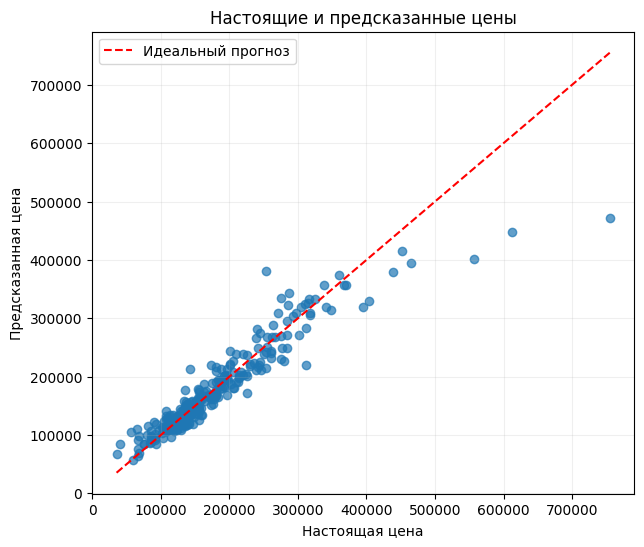

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred, alpha=0.7)

limits = [
    min(y_test.min(), test_pred.min()),
    max(y_test.max(), test_pred.max()),
]
plt.plot(limits, limits, "--", color="red", label="Идеальный прогноз")

plt.xlabel("Настоящая цена")
plt.ylabel("Предсказанная цена")
plt.title("Настоящие и предсказанные цены")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [18]:
import joblib
import numpy as np

joblib.dump(final_model, "ames_house_price_model.joblib")

loaded_model = joblib.load("ames_house_price_model.joblib")
loaded_pred = loaded_model.predict(X_test)

print(
    "Предсказания совпадают:",
    np.allclose(test_pred, loaded_pred)
)

Предсказания совпадают: True


## Итоги

Была построена модель прогнозирования стоимости домов на данных Ames Housing.

В ходе работы:

- создан baseline, предсказывающий медианную цену;
- числовые и категориальные признаки обработаны внутри Pipeline;
- исключена утечка данных при кросс-валидации;
- сравнены Ridge, Log-Ridge, Random Forest и Gradient Boosting;
- параметры итоговой модели подобраны только на обучающей выборке;
- тестовая выборка использована один раз для финальной оценки.

### Результаты итоговой модели

- CV MAE: 16 276
- Test MAE: 17 271
- Test RMSE: 30 503
- Test R²: 0.879
- улучшение MAE относительно baseline: 71%

### Ограничения

На тестовой выборке модель хуже работает в верхнем ценовом квартиле:
MAE дорогих домов составляет 34 077 против 10–13 тысяч в средних
ценовых сегментах. Модель склонна переоценивать дешёвые и
недооценивать дорогие дома.

Итоговый Pipeline сохранён в файл `ames_house_price_model.joblib`.